In [1]:
import os
from modules_test_eval import *
import torch
import cv2
import matplotlib.pyplot as plt

In [3]:

def show(img, title = None):
    '''
    plot an an cv2 image
    for use in notebooks
    '''
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.axis('off')
    if title: plt.title(title) 
    plt.show()



def draw_bounding_boxes(image, rectangles, color=(255, 0, 0), thickness=2):
    '''
    returns image and the bounding boxes calculated
    '''
    img_copy = image.copy()
    for x1, y1, x2, y2 in rectangles:
        cv2.rectangle(img_copy, (x1, y1), (x2, y2), color, thickness)
    print(f"{len(rectangles)} bounding boxes found.")
    return img_copy

### Loading the labels

In [7]:
images = os.listdir("/user/christoph.wald/u15287/big-scratch/02_splitted_data/test_set/SSL/03_images_masked")
image_file = images[1]
image_file = "TRIAVA_0626.jpg"
print(image_file)

TRIAVA_0626.jpg


In [8]:
labels_folder = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/test_set/SSL/04_labels_cropped"
created_labels_folder = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/test_set/SSL/05_created_labels"
label_file = os.path.splitext(image_file)[0] + ".txt"
label_path = os.path.join(labels_folder, label_file)
with open(label_path, "r") as f:
    yolo_rectangles = [
        tuple(map(int, line.strip("()\n ").split(",")))
        for line in f
    ]
yolo_rectangles = [(x, y, x + w, y + h) for (x, y, w, h) in yolo_rectangles]
print(yolo_rectangles[:3])
label_file = os.path.splitext(image_file)[0] + ".txt"
label_path = os.path.join(created_labels_folder, label_file)
with open(label_path, "r") as f:
    rectangles = [
        tuple(map(int, line.strip("()\n ").split(",")))
        for line in f
    ]
print(rectangles[:3])

[(3989, 1611, 4041, 1675), (4407, 1269, 4467, 1302), (4028, 1042, 4062, 1101)]
[(3057, 2155, 3093, 2192), (744, 2129, 819, 2178), (1498, 2030, 1571, 2087)]


In [9]:
img = cv2.imread(os.path.join("/user/christoph.wald/u15287/big-scratch/02_splitted_data/test_set/SSL/04_images_cropped", image_file))
show(img)
show(draw_bounding_boxes(img, yolo_rectangles, color = (0,255,0)))
show(draw_bounding_boxes(img, rectangles, color=(0,0,125)))

NameError: name 'show' is not defined

### Calculate like in 05b create rectangles

In [10]:
#rectangles = [(x, y, x + w, y + h) for (x, y, w, h) in rectangles]

stats, fp_boxes = evaluate_detections(rectangles, yolo_rectangles)
#fp_boxes = [(x1, y1, x2-x1, y2-y1) for (x1,y1, x2, y2) in fp_boxes]
print(stats)

{'TP': 15, 'FP': 13, 'FN': 40}


In [11]:
species = ["BRAIIM","LIRIBO", "FRANOC", "TRIAVA"]
index = next((i for i, sp in enumerate(species) if image_file.startswith(sp)), None)
class_ids = [index]*len(rectangles)
confs = [1.0] * len(rectangles)
label_classes_ids = [index] * len(yolo_rectangles)
tp, fp, fn = evaluate_detections(rectangles,class_ids, confs, yolo_rectangles, label_classes_ids)
print(len(tp[0]), len(fp[0]), len(fn[0]))

TypeError: evaluate_detections() takes from 2 to 3 positional arguments but 5 were given

13 bounding boxes found.


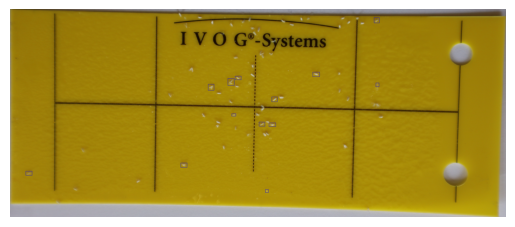

In [27]:
show(draw_bounding_boxes(img,fp_boxes))

### Calculate like in test_full_images

In [12]:
species = ["BRAIIM","LIRIBO", "FRANOC", "TRIAVA"]
index = next((i for i, sp in enumerate(species) if image_file.startswith(sp)), None)
class_ids = [index]*len(rectangles)
confs = [1.0] * len(rectangles)
label_classes_ids = [index] * len(yolo_rectangles)
tp, fp, fn = compare_labels(pred_boxes=rectangles, pred_classes=class_ids, pred_scores=confs,gt_boxes=yolo_rectangles, gt_classes=label_classes_ids, 
                                iou_threshold = 0.5,
                                containment_threshold = 0.8)
print(len(tp[0]), len(fp[0]), len(fn[0]))

20 8 35


8 bounding boxes found.


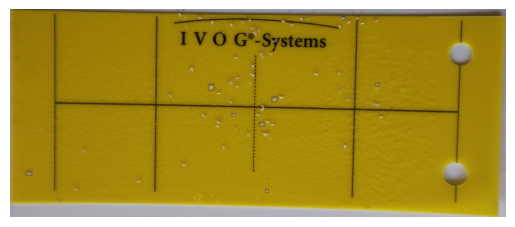

In [29]:
show(draw_bounding_boxes(img, fp[0]))

35 bounding boxes found.


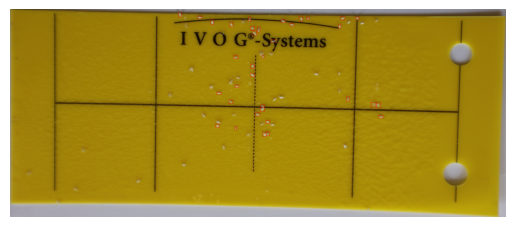

In [30]:
show(draw_bounding_boxes(img, fn[0], color = (0,0,255)))

### Calculate like in evaluate

In [52]:
pred_boxes = torch.tensor(rectangles, dtype=torch.float32).to("cuda")
#pred_boxes = torch.stack([x1, y1, x2, y2], dim=1)

# Derive class ID from filename
species = ["BRAIIM", "LIRIBO","FRANOC", "TRIAVA"]  # adjust as needed
row_index = next((i for i, sp in enumerate(species) if image_file.startswith(sp)), len(species))
pred_classes = torch.tensor([row_index]*len(pred_boxes), dtype=torch.long).to("cuda")
label_boxes = torch.tensor(yolo_rectangles, dtype= torch.float32).to("cuda")
label_classes = torch.tensor([row_index]*len(label_boxes), dtype=torch.long).to("cuda")
tp, fp, fn = compare_labels_vectorized(
            pred_boxes, pred_classes, torch.ones(len(pred_boxes)).to("cuda"),  # dummy conf=1
            label_boxes, label_classes,
            tile_size=640, iou_threshold=0.5, containment_threshold=0.8, convert_to_xyxy=False
        )
print(len(tp[0]), len(fp[0]), len(fn[0]))

2 6 4


In [25]:
images = os.listdir("/user/christoph.wald/u15287/big-scratch/02_splitted_data/test_set/SSL/03_images_masked")
counter = 0
collect_iop = [0,0,0]
collect_ioucont = [0,0,0]
for image_file in images:
    labels_folder = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/test_set/SSL/04_labels_cropped"
    created_labels_folder = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/test_set/SSL/05_created_labels"
    label_file = os.path.splitext(image_file)[0] + ".txt"
    label_path = os.path.join(labels_folder, label_file)
    with open(label_path, "r") as f:
        yolo_rectangles = [
            tuple(map(int, line.strip("()\n ").split(",")))
            for line in f
        ]
    
    label_file = os.path.splitext(image_file)[0] + ".txt"
    label_path = os.path.join(created_labels_folder, label_file)
    with open(label_path, "r") as f:
        rectangles = [
            tuple(map(int, line.strip("()\n ").split(",")))
            for line in f
        ]

    #rectangles = [(x, y, x + w, y + h) for (x, y, w, h) in rectangles]
    yolo_rectangles = [(x, y, x + w, y + h) for (x, y, w, h) in yolo_rectangles]
    stats, fp_boxes = evaluate_detections(rectangles, yolo_rectangles)
    fp_boxes = [(x1, y1, x2-x1, y2-y1) for (x1,y1, x2, y2) in fp_boxes]
    
    species = ["BRAIIM","LIRIBO", "FRANOC", "TRIAVA"]
    index = next((i for i, sp in enumerate(species) if image_file.startswith(sp)), None)
    class_ids = [index]*len(rectangles)
    confs = [1.0] * len(rectangles)
    label_classes_ids = [index] * len(yolo_rectangles)
    tp, fp, fn = compare_labels(pred_boxes=rectangles, pred_classes=class_ids, pred_scores=confs,gt_boxes=yolo_rectangles, gt_classes=label_classes_ids, 
                                    iou_threshold = 0.5,
                                    containment_threshold = 0.8)
    
    #if stats["TP"] != len(tp[0]) or stats["FP"] != len(fp[0]) or stats["FN"] != len(fn[0]):
    #print(stats)
    #print(len(tp[0]), len(fp[0]), len(fn[0]))
    collect_iop[0] += stats["TP"]
    collect_iop[1] += stats["FP"]
    collect_iop[2] += stats["FN"]
    collect_ioucont[0] += len(tp[0])
    collect_ioucont[1] += len(fp[0])
    collect_ioucont[2] += len(fn[0])
    
    counter += 1
    print(image_file)
print(counter)
print(len(images))

TRIAVA_0626.jpg
LIRIBO_0273.jpg
TRIAVA_0184.jpg
TRIAVA_0237.jpg
BRAIIM_0170.jpg
TRIAVA_0501.jpg
LIRIBO_0649.jpg
LIRIBO_0008.jpg
LIRIBO_0274.jpg
BRAIIM_1161.jpg
BRAIIM_0821.jpg
BRAIIM_0288.jpg
LIRIBO_0340.jpg
TRIAVA_0140.jpg
LIRIBO_0049.jpg
TRIAVA_0500.jpg
BRAIIM_0416.jpg
LIRIBO_0218.jpg
BRAIIM_0693.jpg
LIRIBO_0635.jpg
LIRIBO_0457.jpg
TRIAVA_0467.jpg
LIRIBO_0107.jpg
BRAIIM_0944.jpg
BRAIIM_1128.jpg
BRAIIM_1183.jpg
LIRIBO_0011.jpg
LIRIBO_0091.jpg
LIRIBO_0346.jpg
BRAIIM_0286.jpg
TRIAVA_0485.jpg
LIRIBO_0021.jpg
LIRIBO_0323.jpg
LIRIBO_0131.jpg
LIRIBO_0525.jpg
BRAIIM_0302.jpg
LIRIBO_0517.jpg
TRIAVA_0358.jpg
LIRIBO_0471.jpg
LIRIBO_0488.jpg
LIRIBO_0126.jpg
LIRIBO_0210.jpg
LIRIBO_0168.jpg
LIRIBO_0673.jpg
LIRIBO_0174.jpg
LIRIBO_0397.jpg
LIRIBO_0268.jpg
LIRIBO_0132.jpg
LIRIBO_0181.jpg
LIRIBO_0098.jpg
BRAIIM_1047.jpg
LIRIBO_0413.jpg
LIRIBO_0209.jpg
LIRIBO_0242.jpg
LIRIBO_0416.jpg
BRAIIM_0913.jpg
BRAIIM_1044.jpg
BRAIIM_0477.jpg
LIRIBO_0277.jpg
LIRIBO_0145.jpg
TRIAVA_0465.jpg
LIRIBO_0083.jpg
LIRIBO_0

In [26]:
collect_iop

[2096, 421, 2689]

In [28]:
collect_ioucont

[2072, 445, 2713]

In [22]:
def calc_metrics(counts):
    print(f"Precision {counts[0]/(counts[0]+counts[1])}")
    print(f"Recall {counts[0]/(counts[0]+counts[2])}")

In [27]:
calc_metrics(collect_iop)

Precision 0.8327373857767183
Recall 0.4380355276907001


In [24]:
calc_metrics(collect_ioucont)

Precision 0.823202224870878
Recall 0.4330198537095089
